# Mass/redshift-masked tSZ power spectrum

Instead of an SNR-based completeness, here we apply a **simple top-hat selection in $(M_{500c}, z)$**: we mask the **local, massive** clusters, those with $z<z_{\rm cut}$ **and** $M_{500c}>M_{\rm cut}$, the nearby large-angular-size objects that dominate the intermediate-$\ell$ tSZ signal. We apply the *identical* $(M,z)$ cut to the halo-model integrand and check the masked map is still fit by the masked theory.

**Map side.** Cut a $R_{\rm mask}\,\theta_{500}$ disc around every catalogue cluster with $z<z_{\rm cut}$ and $M_{500c}>M_{\rm cut}$, apodize the mask, and estimate the **mask-decoupled** bandpowers with **NaMaster** (mode-coupling deconvolution; mask-weighted monopole subtracted), then deconvolve the pixel window.

**Theory side.** D3A cosmology, tSZ tracer with Arnaud A10 GNFW and $B=1.0$. The mask is $\mathcal{M}(M,z)=1-\Theta(M_{500c}-M_{\rm cut})\,\Theta(z_{\rm cut}-z)$, i.e. zero in the masked corner and one elsewhere; the halo-model native mass is converted to $M_{500c}$ so the cut matches the catalogue.

In [1]:
import os

# Control JAX GPU memory to use only 10%
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.10"

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# Publication-quality plot defaults
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

import jax.numpy as jnp

from flamingo import paths
from flamingo.maps import read_map
from flamingo.catalogue import load_catalogue, D3A_COSMOLOGY
from flamingo.geometry import query_disc_separation, ARCMIN_PER_RAD
from hmfast.halos import HaloModel, convert_m_delta, MassDefinition
from hmfast.halos.profiles import GNFWPressureProfile
from hmfast.tracers import tSZTracer

ymap = read_map(paths.HYDRO_MAP)
df = load_catalogue(paths.HYDRO_CATALOGUE)
NSIDE = hp.npix2nside(ymap.size)
print('NSIDE', NSIDE, '| clusters', len(df))


NSIDE 4096 | clusters 1555542


In [2]:
# Top-hat selection: mask local AND massive clusters.
Z_CUT = 1.0          # mask z < Z_CUT
M_CUT = 1.0e14       # and M500c > M_CUT [Msun]
R_MASK = 5.0         # mask radius in units of theta500
LMAX = 6000

sel = (df['z'] < Z_CUT) & (df['M_500c_Msun'] > M_CUT)
masked_clusters = df[sel]
print(f'masked (z<{Z_CUT} & M500c>{M_CUT:.1e}): {len(masked_clusters)} clusters')

masked (z<1.0 & M500c>1.0e+14): 273993 clusters


## Masked map power spectrum

In [3]:
mask = np.ones(ymap.size, dtype=np.float64)
for _, row in masked_clusters.iterrows():
    r_rad = R_MASK * float(row['theta500_arcmin']) / ARCMIN_PER_RAD
    pix, _ = query_disc_separation(NSIDE, float(row['theta_rot_rad']),
                                   float(row['phi_rot_rad']), r_rad)
    mask[pix] = 0.0
print(f'f_sky (binary) = {mask.mean():.4f}')
ell = np.arange(LMAX + 1)        # integer multipoles (used by the raw-Cl cell below)

from flamingo.powerspectra import apodize, decoupled_dl
mask_apo = apodize(mask, aperture_deg=0.5)

# Mask-decoupled bandpowers via NaMaster: proper mode-coupling deconvolution
# (NOT a scalar 1/fsky rescale), mask-weighted monopole subtracted internally,
# then deconvolve the HEALPix pixel window. Unmasked = full sky.
# Small delta_ell keeps fine sampling at large scales (low ell); a small-hole
# mask has its power at high ell, so narrow low-ell bins stay well-conditioned.
DELL = 20
pwf = hp.pixwin(NSIDE, lmax=LMAX)


def dl_nmt(weight):
    ell_eff, _, cl = decoupled_dl(ymap, weight, delta_ell=DELL, lmax=LMAX)
    pw_eff = np.interp(ell_eff, np.arange(pwf.size), pwf)
    cl = cl / pw_eff**2
    return ell_eff, ell_eff * (ell_eff + 1) / (2 * np.pi) * cl


ellb, dl_unmasked_b = dl_nmt(None)           # full-sky reference
_, dl_masked_b = dl_nmt(mask_apo)            # (M,z)-selected mask

f_sky (binary) = 0.5069


## Theory with the same $(M,z)$ top-hat

The halo-model native mass (200c) is converted to $M_{500c}$ on the $(M,z)$ grid, so the theory cut is applied in the same mass definition as the catalogue. The mask is a sharp $0/1$ top-hat, shared by the 1-halo and 2-halo terms.

In [4]:
A10 = dict(P0=8.403, c500=1.177, gamma=0.3081, alpha=1.0510, beta=5.4905)
tracer = tSZTracer(profile=GNFWPressureProfile(**A10, B=1.0))
hm = HaloModel(cosmology=D3A_COSMOLOGY)

ell_th = jnp.logspace(1.0, np.log10(LMAX), 40)
m = jnp.logspace(11.0, 15.5, 100)      # physical Msun
z = jnp.geomspace(0.001, 3.0, 100)

# Convert native mass -> M500c on the (M,z) grid to apply the catalogue-matched cut.
mdef_500c = MassDefinition(500, 'critical')
c_old = hm.concentration.c_delta(hm, m, z)
m500c = convert_m_delta(hm.cosmology, m, z, hm.mass_definition, mdef_500c, c_old=c_old)  # (Nm,Nz)

masked_region = (m500c > M_CUT) & (z[None, :] < Z_CUT)
mask_mz = jnp.where(masked_region, 0.0, 1.0)                  # (Nm,Nz)
print('fraction of (M,z) grid masked:', float(jnp.mean(masked_region)))

ell_np = np.asarray(ell_th)
pref_th = ell_np * (ell_np + 1) / (2 * np.pi)

cl1h_m = np.asarray(hm.cl_1h_masked(tracer, tracer, l=ell_th, m=m, z=z, mask_mz=mask_mz))
cl2h_m = np.asarray(hm.cl_2h_masked(tracer, tracer, l=ell_th, m=m, z=z, mask_mz=mask_mz))
dl_th_masked = pref_th * (cl1h_m + cl2h_m)

cl1h = np.asarray(hm.cl_1h(tracer, tracer, l=ell_th, m=m, z=z))
cl2h = np.asarray(hm.cl_2h(tracer, tracer, l=ell_th, m=m, z=z))
dl_th_full = pref_th * (cl1h + cl2h)

fraction of (M,z) grid masked: 0.25759997963905334


In [5]:
# --- Same (M,z) top-hat, but with the Mira-Titan HMF (native M200c) ---
# Emulator valid for z <= 2 and M200c >~ 1.5e13 Msun, so use its own (m_mt, z_mt) grid.
from hmfast.halos.massfunc import MTHaloMass

mt = MTHaloMass(); mt.prepare(D3A_COSMOLOGY)
hm_mt = HaloModel(cosmology=D3A_COSMOLOGY, halo_mass_function=mt)
z_mt = jnp.geomspace(0.001, 2.0, 60)
m_mt = jnp.logspace(np.log10(1.5e13), 15.5, 50)   # Mira-Titan valid mass range

c_old_mt = hm.concentration.c_delta(hm, m_mt, z_mt)
m500c_mt = convert_m_delta(hm.cosmology, m_mt, z_mt, hm.mass_definition, mdef_500c, c_old=c_old_mt)
masked_region_mt = (m500c_mt > M_CUT) & (z_mt[None, :] < Z_CUT)
mask_mz_mt = jnp.where(masked_region_mt, 0.0, 1.0)

cl1h_m_mt = np.asarray(hm_mt.cl_1h_masked(tracer, tracer, l=ell_th, m=m_mt, z=z_mt, mask_mz=mask_mz_mt))
cl2h_m_mt = np.asarray(hm_mt.cl_2h_masked(tracer, tracer, l=ell_th, m=m_mt, z=z_mt, mask_mz=mask_mz_mt))
dl_th_masked_mt = pref_th * (cl1h_m_mt + cl2h_m_mt)
print('Mira-Titan masked D_ell at ell~3000:', float(np.interp(3000, ell_np, dl_th_masked_mt)))

Mira-Titan masked D_ell at ell~3000: 4.020032659443737e-13


In [6]:
# --- Low-ell (point-source) 1-halo normalization of the MASKED map ---
# Survivors = clusters OUTSIDE the masked (M,z) corner. Residual 1-halo white level:
# C -> (1/4pi) sum_surv Y_ang^2, with Y_ang = Y_5R500c_Mpc2 / d_A^2.
from hmfast.halos.massfunc import T08HaloMass

_z = df['z'].values
_dA = df['r_comoving_Mpc'].values / (1 + _z)
y_ang = df['Y_5R500c_Mpc2'].values / _dA**2
surv = ~((df['z'].values < Z_CUT) & (df['M_500c_Msun'].values > M_CUT))   # outside the cut

C_white_cat = np.sum(y_ang[surv]**2) / (4 * np.pi)

# Tinker08-HMF version: survivor sum(Y^2) per (logM500c,z) bin, reweighted by T08/cat counts.
mE = np.arange(13.7, 15.7, 0.1); zE = np.linspace(0.0, 3.0, 31)
lm = np.log10(df['M_500c_Msun'].values)
Ssurv, _, _ = np.histogram2d(lm, _z, bins=[mE, zE], weights=np.where(surv, y_ang**2, 0.0))
Ncat, _, _ = np.histogram2d(lm, _z, bins=[mE, zE])
hm5w = HaloModel(cosmology=D3A_COSMOLOGY, mass_definition=MassDefinition(500, 'critical'),
                 halo_mass_function=T08HaloMass())
mc = 0.5 * (mE[:-1] + mE[1:]); zc = 0.5 * (zE[:-1] + zE[1:])
dnw = np.asarray(hm5w.halo_mass_function.halo_mass_function(hm5w, jnp.asarray(10**mc), jnp.asarray(zc)))
dVw = np.asarray(D3A_COSMOLOGY.comoving_volume_element(jnp.asarray(zc)))
N_T08 = 4 * np.pi * dVw[None, :] * dnw * (np.log(10) * 0.1) * (zE[1] - zE[0])
ratio = np.where(Ncat > 0, N_T08 / np.maximum(Ncat, 1), 0.0)
C_white_T08 = np.sum(Ssurv * ratio) / (4 * np.pi)

ell_w = np.logspace(1.0, np.log10(300.0), 40)
dl_white_cat = ell_w * (ell_w + 1) / (2 * np.pi) * C_white_cat
dl_white_T08 = ell_w * (ell_w + 1) / (2 * np.pi) * C_white_T08
print('masked C_white (survivors): cat=%.3e  Tinker08=%.3e' % (C_white_cat, C_white_T08))

masked C_white (survivors): cat=5.189e-17  Tinker08=4.830e-17


## $D_\ell$ vs $\ell$: masked map vs masked theory

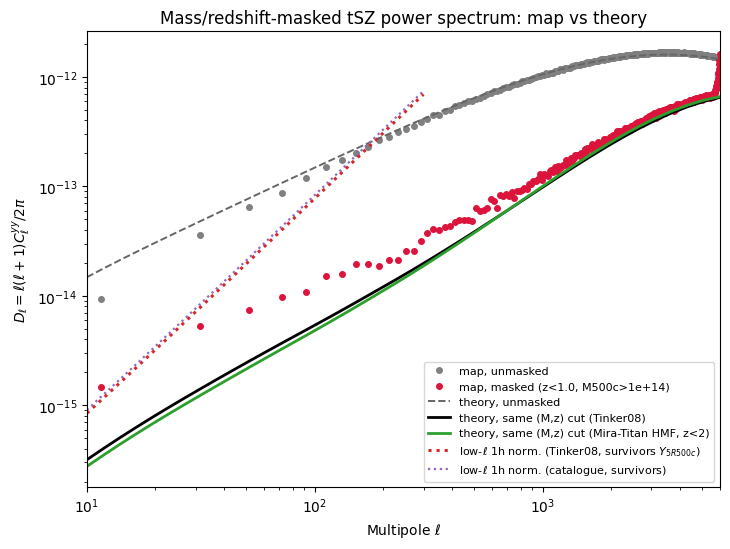

In [7]:
fig, ax = plt.subplots(figsize=(7.4, 5.6))
ax.loglog(ellb, dl_unmasked_b, 'o', ms=4, color='0.5', label='map, unmasked')
ax.loglog(ellb, dl_masked_b, 'o', ms=4, color='crimson',
          label=f'map, masked (z<{Z_CUT}, M500c>{M_CUT:.0e})')
ax.loglog(ell_np, dl_th_full, '--', lw=1.4, color='0.4', label='theory, unmasked')
ax.loglog(ell_np, dl_th_masked, 'k-', lw=2, label='theory, same (M,z) cut (Tinker08)')
ax.loglog(ell_np, dl_th_masked_mt, '-', lw=2, color='C2',
          label='theory, same (M,z) cut (Mira-Titan HMF, z<2)')
ax.loglog(ell_w, dl_white_T08, ':', color='C3', lw=2.2,
          label=r'low-$\ell$ 1h norm. (Tinker08, survivors $Y_{5R500c}$)')
ax.loglog(ell_w, dl_white_cat, ':', color='C4', lw=1.6,
          label=r'low-$\ell$ 1h norm. (catalogue, survivors)')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell^{yy}/2\pi$')
ax.set_title('Mass/redshift-masked tSZ power spectrum: map vs theory')
ax.set_xlim(10, LMAX)
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

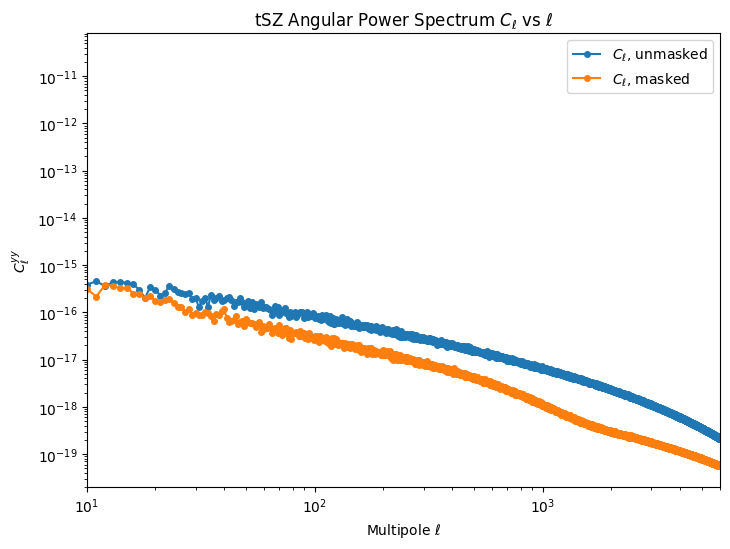

In [8]:
# Plot Cl (cell) against ell
fig, ax = plt.subplots(figsize=(7.4, 5.6))
ax.loglog(ell, hp.anafast(ymap, lmax=LMAX), 'o-', ms=4, color='C0', label=r'$C_\ell$, unmasked')
ax.loglog(ell, hp.anafast(ymap * mask, lmax=LMAX), 'o-', ms=4, color='C1', label=r'$C_\ell$, masked')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$C_\ell^{yy}$')
ax.set_title('tSZ Angular Power Spectrum $C_\\ell$ vs $\\ell$')
ax.set_xlim(10, LMAX)
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()